# Loading the dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("perceptron_data.txt", sep='\t')

In [3]:
df

,x1,x2,label
0,3.28,3.20,0
1,1.91,3.00,0
2,3.26,1.81,0
3,7.78,5.83,1
4,6.81,5.51,1
5,4.86,2.63,0
6,3.81,3.21,0
7,6.20,6.21,1
8,7.74,6.16,1
9,4.87,1.56,0


In [4]:
X_train = df[["x1", "x2"]].values

In [5]:
y_train = df["label"].values

In [6]:
import torch

X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)

In [7]:
X_train

tensor([[3.2800, 3.2000],
        [1.9100, 3.0000],
        [3.2600, 1.8100],
        [7.7800, 5.8300],
        [6.8100, 5.5100],
        [4.8600, 2.6300],
        [3.8100, 3.2100],
        [6.2000, 6.2100],
        [7.7400, 6.1600],
        [4.8700, 1.5600],
        [6.8900, 6.9800],
        [6.4800, 9.0700],
        [7.0700, 7.1400],
        [4.6600, 2.6600],
        [6.4700, 7.6500],
        [5.3800, 7.0000],
        [5.9200, 1.6800],
        [2.6200, 1.8400],
        [7.3000, 6.3400],
        [3.5900, 2.3700],
        [4.7100, 5.2200],
        [3.5700, 1.3500],
        [6.0400, 8.0900],
        [6.3900, 6.5600],
        [4.5100, 3.7300],
        [3.0200, 3.3600],
        [6.5100, 7.6600],
        [5.8100, 7.2100],
        [6.0400, 6.2000],
        [2.1800, 1.4500]], dtype=torch.float64)

In [8]:
y_train

tensor([0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
        0, 0, 1, 1, 1, 0])

In [9]:
X_train = X_train.to(torch.float32)
y_train = y_train.to(torch.float32)

In [10]:
np.bincount(y_train)

/var/folders/nm/l7gn1r715fb3302p64y3pjth0000gn/T/ipykernel_24287/1006443715.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  np.bincount(y_train)


array([15, 15])

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

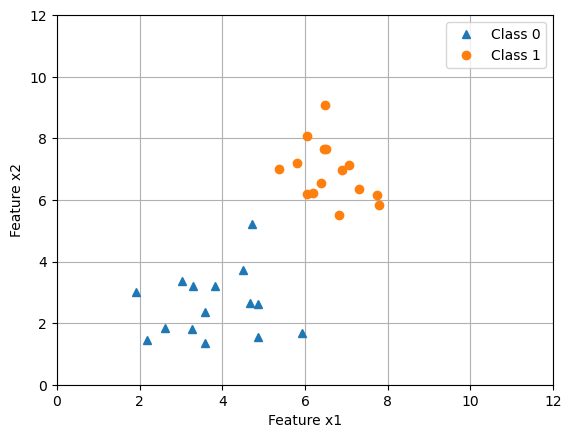

In [12]:
plt.plot(X_train[y_train==0, 0], X_train[y_train==0, 1], '^', label="Class 0")
plt.plot(X_train[y_train==1, 0], X_train[y_train==1, 1], 'o', label="Class 1")
plt.ylim(0,12)
plt.xlim(0,12)
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.legend()
plt.grid()
plt.show()

# Vectorized Perceptron Class

In [13]:
class Perceptron:
    def __init__(self, num_features):
        #self.weights = [0.0 for _ in range(num_features)]
        self.weights = torch.zeros(num_features)
        #self.bias = 0.0
        self.bias = torch.tensor(0.0)

    def forward(self, x):
        #z_weighted_sum = self.bias
        #for i, _ in enumerate(self.weights):
        #    z_weighted_sum += x[i] * self.weights[i]

        z_weighted_sum = torch.dot(self.weights, x) + self.bias
        

        if z_weighted_sum > 0.0:
            #prediction = 1
            prediction = torch.tensor(1.)
        else:
            #prediction = 0
            prediction = torch.tensor(0.)

        return prediction

    def update(self, x, true_y):
        y_hat = self.forward(x)
        error = true_y - y_hat

        self.bias += error
        #for i, _ in enumerate(self.weights):
        #    self.weights[i] += error*x[i]

        self.weights += error * x

        return error

In [14]:
pn = Perceptron(num_features=2)

In [15]:
pn.weights

tensor([0., 0.])

In [16]:
pn.bias

tensor(0.)

In [17]:
# x = [1.0, 2.0]
x = torch.tensor([1., 2.])

In [18]:
pn.forward(x)

tensor(0.)

In [19]:
pn.update(x, 1)

tensor(1.)

In [20]:
pn.weights

tensor([1., 2.])

In [21]:
pn.bias

tensor(1.)

# Train function

In [22]:
def train(model, X_data, y_labels, epochs):
    for epoch in range(epochs):
        error_count = 0
        
        for x, y in zip(X_data, y_labels):
            error = model.update(x, y)
            error_count += abs(error)
            
        print(f'Epoch {epoch + 1}, errors {error_count}')

In [23]:
pn = Perceptron(2)

In [24]:
train(pn, X_train, y_train, epochs=120)

Epoch 1, errors 17.0
Epoch 2, errors 15.0
Epoch 3, errors 11.0
Epoch 4, errors 11.0
Epoch 5, errors 10.0
Epoch 6, errors 10.0
Epoch 7, errors 7.0
Epoch 8, errors 8.0
Epoch 9, errors 6.0
Epoch 10, errors 5.0
Epoch 11, errors 8.0
Epoch 12, errors 6.0
Epoch 13, errors 5.0
Epoch 14, errors 8.0
Epoch 15, errors 5.0
Epoch 16, errors 7.0
Epoch 17, errors 7.0
Epoch 18, errors 5.0
Epoch 19, errors 5.0
Epoch 20, errors 5.0
Epoch 21, errors 7.0
Epoch 22, errors 7.0
Epoch 23, errors 5.0
Epoch 24, errors 5.0
Epoch 25, errors 5.0
Epoch 26, errors 4.0
Epoch 27, errors 4.0
Epoch 28, errors 5.0
Epoch 29, errors 5.0
Epoch 30, errors 5.0
Epoch 31, errors 5.0
Epoch 32, errors 4.0
Epoch 33, errors 4.0
Epoch 34, errors 5.0
Epoch 35, errors 5.0
Epoch 36, errors 5.0
Epoch 37, errors 4.0
Epoch 38, errors 4.0
Epoch 39, errors 5.0
Epoch 40, errors 5.0
Epoch 41, errors 4.0
Epoch 42, errors 3.0
Epoch 43, errors 3.0
Epoch 44, errors 4.0
Epoch 45, errors 3.0
Epoch 46, errors 3.0
Epoch 47, errors 5.0
Epoch 48, errors

# Evaluate the accuracy

In [25]:
def compute_accuracy(model, X_data, y_label):
    correct = 0.0 
    
    for x, y in zip(X_data, y_label):
        prediction = model.forward(x)
        correct += int(prediction == y)
    
    return correct / len(y_label)

In [26]:
train_acc = compute_accuracy(pn, X_train, y_train)

In [27]:
print(f'Accuracy: {train_acc*100}%')

Accuracy: 100.0%


# Plot decision boundary

In [28]:
def plot_decision_boundary(model):
    w1 = model.weights[0]
    w2 = model.weights[1]
    b = model.bias
    
    assert w2 != 0
    
    x1_min = -100
    x2_min = (-b -(w1 * x1_min)) / w2
    
    x1_max = 100
    x2_max =( -b -(w1 * x1_max)) / w2
    
    return x1_min, x2_min, x1_max, x2_max


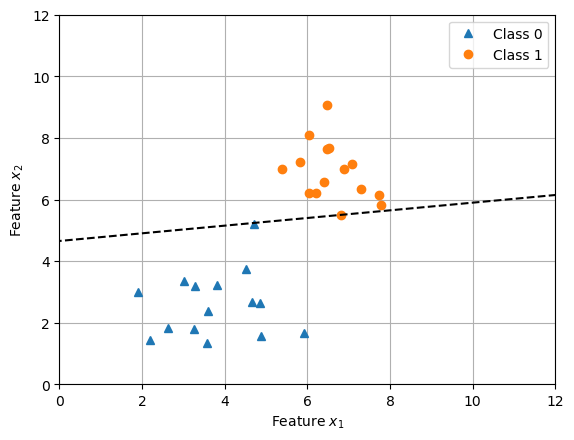

In [29]:
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], '^', label="Class 0")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 'o', label="Class 1")
plt.ylim(0,12)
plt.xlim(0,12)
plt.xlabel("Feature $x_1$")
plt.ylabel("Feature $x_2$")
plt.legend()
plt.grid()

x1_min, x2_min, x1_max, x2_max = plot_decision_boundary(pn)
plt.plot([x1_min, x1_max], [x2_min, x2_max], 'k--')

plt.show()